# Time Series Mean Reversion

Here real data is analyzed for mean reversion by using a stationary ARIMA model and a Fractional Brownian motion model

In [65]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot
from pandas import DataFrame, read_csv

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.plots import curve, comparison, stack, periodogram, variance_agg, PlotType, mean_reversion_halflife
from lib.data import arima, adf, stats, fbm, HypothesisTestType, ou

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Stationary Autoregressive Process 

Stationary autoregressive time series are mean reverting. Here the USD.CAD exchange rate is tested for stationarity using the ADF test. It is seen that the time series is not stationary but it is close to stationary. Using the periodogram method it is found that $H=0.48$ and variance aggregation gives $H=0.45$. The Variance ratio test 

In [8]:
file_path = os.path.abspath('../../algorithmic_trading/data/USD_CAD.csv')
usd_cad = read_csv(file_path, index_col=0, parse_dates=True)
usd_cad.head()

,Close/Last,Volume,Open,High,Low
Date,,,,,
2023-12-08,1.3584,NaN,1.3594,1.3611,1.3551
2023-12-07,1.3577,NaN,1.3594,1.3603,1.3571
2023-12-06,1.3604,NaN,1.3591,1.3608,1.3589
2023-12-05,1.3570,NaN,1.3570,1.3572,1.3531
2023-12-04,1.3558,NaN,1.3537,1.3566,1.3531


In [9]:
date = usd_cad.index.to_numpy()
exch = usd_cad['Close/Last'].to_numpy()
exch_mean = numpy.full(len(date), numpy.mean(exch))

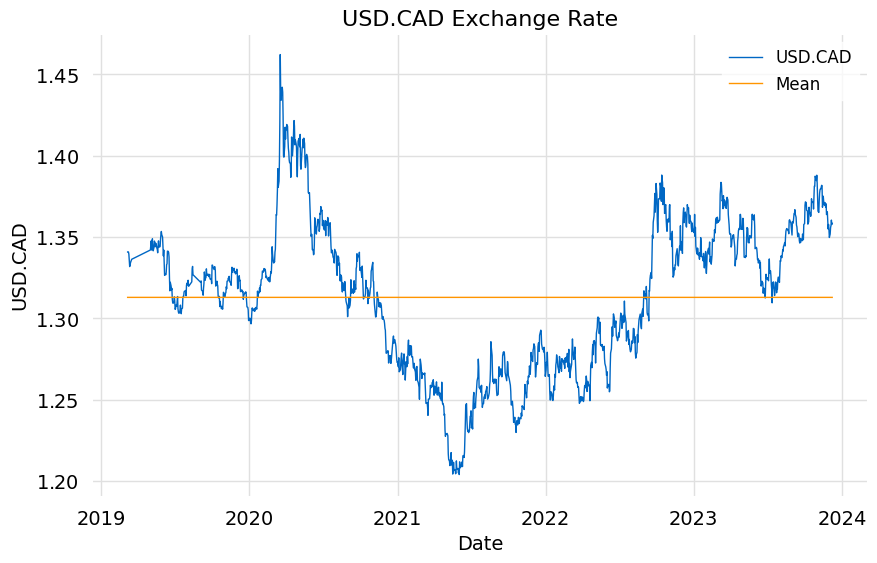

In [60]:
title = 'USD.CAD Exchange Rate'
comparison([exch, exch_mean], date, title=title, xlabel="Date", ylabel="USD.CAD", labels=['USD.CAD', 'Mean'], lw=1)

In [25]:
result, _ = adf.compute_adf_offset_test(exch, max_lag=12)
result.summary()

╒════════════════╤═════════════╕
│ Test Statistic │   -2.16345  │
├────────────────┼─────────────┤
│ pvalue         │    0.219778 │
├────────────────┼─────────────┤
│ Lags           │    5        │
├────────────────┼─────────────┤
│ Number Obs     │ 1409        │
╘════════════════╧═════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -3.435   │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -2.86359 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -2.56786 │ Passed   │
╘════════════════╧══════════════════╧══════════╛


## Fractional Brownian Motion Process

If a fractional brownian motion model is used on the same time series the variance ratio test can be used to test for anticorrelation and the Hurst exponent is estimated using the both the periodogram and variance aggregation methods. The Hurst parameter $H$ is evaluated using both the periodogram method and variance aggregation method. The results are $H=0.48$ and $H=0.45$ respectively. The variance ratio test for anitcorrelation passes. This is consistent with the stationarity test where ADF barley failed.

In [47]:
t, diff_exch = stats.compute_diff(numpy.arange(len(exch)), exch)

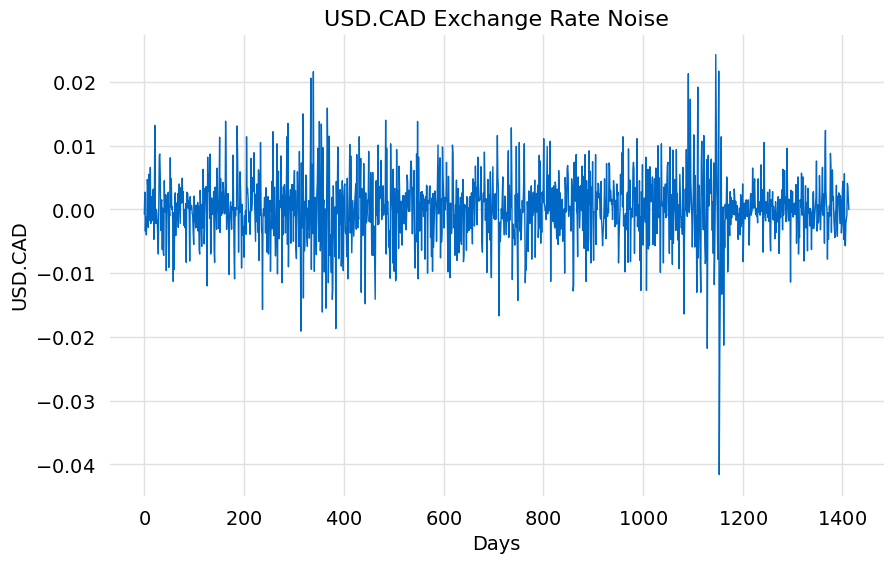

In [48]:
title = 'USD.CAD Exchange Rate Noise'
curve(diff_exch, t, title=title, xlabel="Days", ylabel="USD.CAD", lw=1)

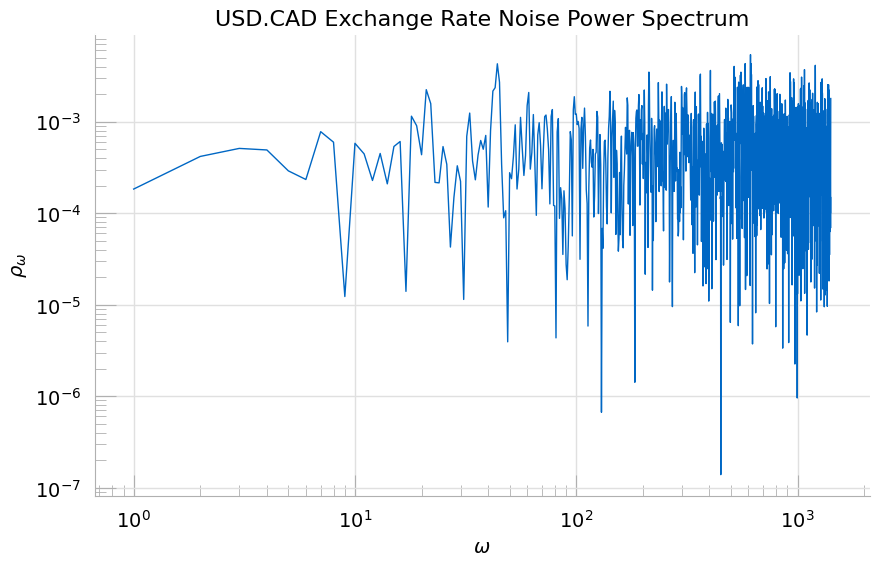

In [49]:
freq, ps = stats.compute_pspec(t, diff_exch)

title = 'USD.CAD Exchange Rate Noise Power Spectrum'
curve(ps, freq, lw=1, title=title, xlabel=r"$\omega$", ylabel=r"$\rho_\omega$", plot_axis_type=PlotType.LOG)

In [50]:
result, result_model = fbm.compute_H_estimate_periodogram(freq, ps)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.143
Date:                Sat, 09 Dec 2023   Prob (F-statistic):              0.285
Time:                        17:42:21   Log-Likelihood:                -1203.2
No. Observations:                1413   AIC:                             2410.
Df Residuals:                    1411   BIC:                             2421.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.5093      0.097    -36.277      0.000      -3.699      -3.320
x1             0.0376      0.035      1.069      0.285      -0.031       0.107
==============================================================================
Omnibus:                      289.052   Durbin-Watson:                   1.385
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              627.992
Skew:                          -1.151   Prob(JB):                    4.30e-137
Kurtosis:                       5.318   Cond. No.                         19.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [51]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": -3.5092826831052277,
      "err": 0.09673481589517371,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "1ba0eaa6-ac28-42b9-83ae-dafc87081d89",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": 0.03760088181539177,
         "err": 0.03516424623930969,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "1ba0eaa6-ac28-42b9-83ae-dafc87081d89",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.0008096822866749953,
   "param_transforms": [
      {
         "param": {
            "est": 0.4811995590923041,
            "err": 0.017582123119654847,
            "est_label": "$\\hat{\u0397}$",
            "err_label": "$\\sigma_{\\hat{\u0397}}$",
            "row": 0,
            "column": 0,
            "

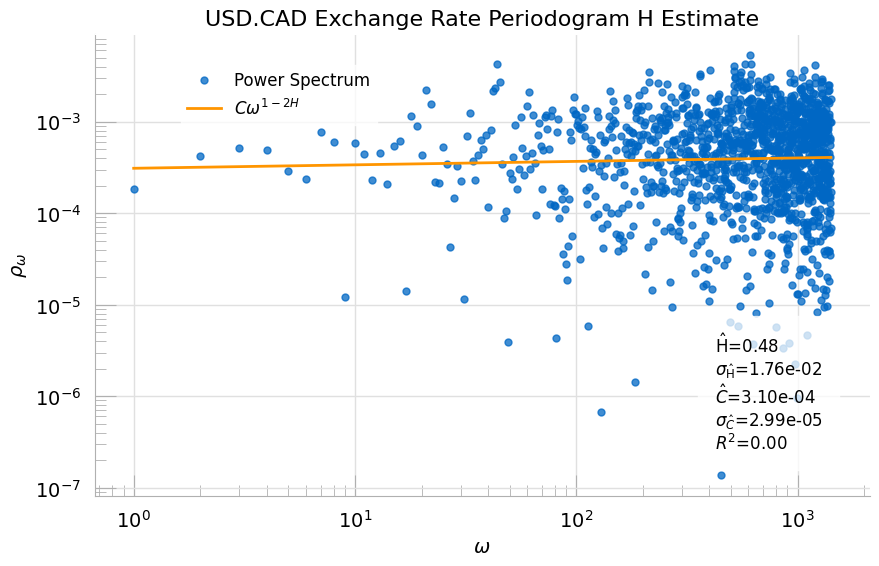

In [52]:
periodogram(ps, result_model, freq, title=f"USD.CAD Exchange Rate Periodogram H Estimate")

In [53]:
nagg = 100
m_vals, agg_var = stats.compute_agg_var(diff_exch, m_max=nagg, npts=nagg)

In [54]:
result, result_model = fbm.compute_H_estimate_variance_aggregation(m_vals, agg_var)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.944
Model:                            OLS   Adj. R-squared:                  0.943
Method:                 Least Squares   F-statistic:                     1638.
Date:                Sat, 09 Dec 2023   Prob (F-statistic):           5.63e-63
Time:                        17:42:36   Log-Likelihood:                 79.929
No. Observations:                 100   AIC:                            -155.9
Df Residuals:                      98   BIC:                            -150.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.4862      0.045   -100.436      0.000      -4.575      -4.398
x1            -1.1092      0.027    -40.472      0.000      -1.164      -1.055
==============================================================================
Omnibus:                       21.663   Durbin-Watson:                   1.788
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               49.399
Skew:                          -0.772   Prob(JB):                     1.88e-11
Kurtosis:                       6.078   Cond. No.                         9.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [55]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": -4.486167375328808,
      "err": 0.04466675835937354,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "aaed2317-dcd6-4c5d-8bd3-93ea2fa8d1a5",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -1.1091744283794778,
         "err": 0.02740613917798426,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "aaed2317-dcd6-4c5d-8bd3-93ea2fa8d1a5",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.943547170651097,
   "param_transforms": [
      {
         "param": {
            "est": 0.4454127858102611,
            "err": 0.01370306958899213,
            "est_label": "$\\hat{\u0397}$",
            "err_label": "$\\sigma_{\\hat{\u0397}}$",
            "row": 0,
            "column": 0,
            "order"

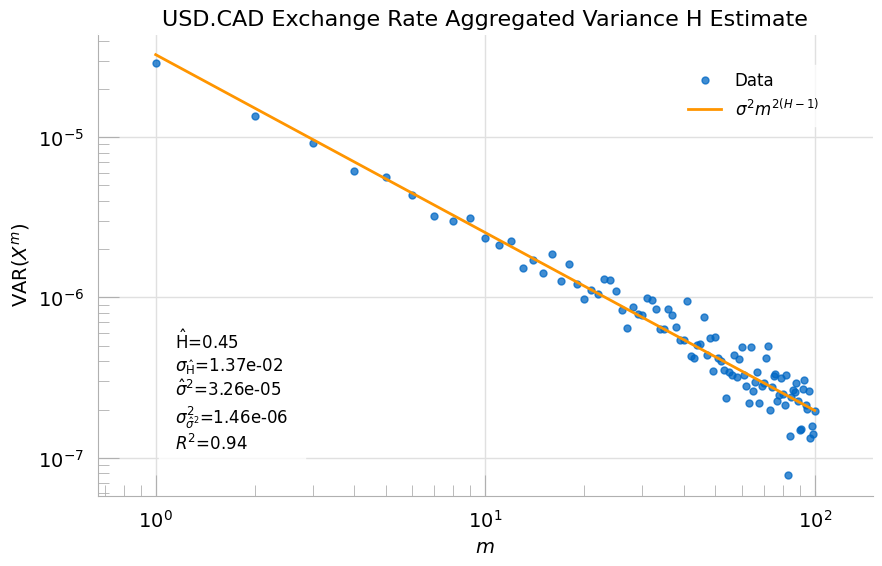

In [56]:
variance_agg(agg_var, result_model, m_vals, title=f"USD.CAD Exchange Rate Aggregated Variance H Estimate")

In [58]:
result, result_model = fbm.compute_vr_test(exch, HypothesisTestType.FBM_NEG_AUTO_CORR)
result.summary()

╒══════════════════════╤══════════════════════════════════════╕
│ Hypothesis Type      │ HypothesisType.LOWER_TAIL            │
├──────────────────────┼──────────────────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.FBM_NEG_AUTO_CORR │
├──────────────────────┼──────────────────────────────────────┤
│ Significance         │ 10%                                  │
├──────────────────────┼──────────────────────────────────────┤
│ Lower Critical Value │ -1.282                               │
╘══════════════════════╧══════════════════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -1.525 │    0.064 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   6 │ -1.281 │    0.1   │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -1.299 │    0.097 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  16 │ -0.827 │    0.204 │ Passed   │
├─────┼────────┼──────────┼───────

In [59]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "NEG_AUTO_CORR",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "test_id": "5e327608-cc18-4441-a492-1df8ac3b026d",
                "label": "$Z(s)$",
                "value": -1.524663783585148
            },
            "pval": {
                "test_id": "5e327608-cc18-4441-a492-1df8ac3b026d",
                "label": "$p-value$",
                "value": 0.06367148968222236
            },
            "params": [
                {
                    "test_id": "5e327608-cc18-4441-a492-1df8ac3b026d",
                    "label": "$s$",
                    "value": 4
                }
            ],
            "sig": {
                "test_id": "5e327608-cc18-4441-a492-1df8ac3b026d",
                "label": "10%",
                "value": 0.1
            },
            "lower": {
                "test_id": "5e327608-cc18-4441-a492-1df8ac3b026d",
        

## Half-Life For Mean Reversion

The $\text{AR}(1)$ process with constant offset is defined by,

$
\begin{align}
X_t = \varphi X_{t-1} + \mu + \sigma \varepsilon_t
\end{align}
\tag{1}
$

where $\varepsilon_t \sim \text{Normal}(0, 1)$. Subtracting $X_{t-1}$ from both sides gives,

$
\begin{align}
\Delta X_t = \left(\varphi - 1 \right) X_{t-1} + \mu + \sigma \varepsilon_t
\end{align}
\tag{2}
$

This can be reparameterized to,

$
\begin{align}
\Delta X_t = \lambda \left(\frac{\mu}{\lambda} + X_{t-1}\right) + \sigma \varepsilon_t
\end{align}
\tag{3}
$

where $\lambda = \varphi - 1$.

The continuous differential form of this equation is the Ornstein-Uhlenbeck SDE,

$
\begin{align}
dX_t = \lambda \left(\frac{\mu}{\lambda} + X_t \right) dt + \sigma dB_t
\end{align}
\tag{4}
$

where $dB_t \sim \text{Normal}(0, dt)$. The Ornstein-Uhlenbeck SDE models a mean reverting random process and can be solved using the integration factor, $e^{-\lambda t}$

$
\begin{align}
X_t = X_0 e^{\lambda t} + \frac{\mu}{\lambda} \left( 1 - e^{\lambda t} \right) + \sigma \int_0^t e^{\lambda\left( t - s \right)} dB_s
\end{align}
\tag{5}
$

The mean value is given by,

$
\begin{align}
\text{E}\left[ X_t \right] = X_0 e^{\lambda t} + \frac{\mu}{\lambda} \left( 1 - e^{\lambda t} \right)
\end{align}
\tag{6}
$

For the limit $t \to \infty$ a finite mean value requires $\lambda < 0$,

$
\begin{align}
\text{E}\left[ X_t \right] = -\frac{\mu}{\lambda}
\end{align}
\tag{7}
$

The half life of mean decay is the time to reach $\frac{1}{2}$ the $t \to \infty$ value from the initial value. This defines the timescale of the Ornstein-Uhlenbeck process. If $t_H$ denotes the half life. It follows that $X_t_H is given by,

$
\begin{align}
X_{t_H} = X_0 - \frac{1}{2}\left(\frac{\mu}{\lambda} + X_0 \right)
\end{align}
\tag{8}
$

Using $Eq(7)$ and $Eq(8)$ and solving for $t_H$ gives,

$
\begin{align}
t_H = -\frac{\ln{2}}{\lambda}
\end{align}
\tag{9}
$

$\lambda$ can be evaluated by using regression on the equation,

$
\begin{align}
\Delta X_t = \lambda X_{t-1} + \mu + \sigma \varepsilon_t
\end{align}
\tag{10}
$



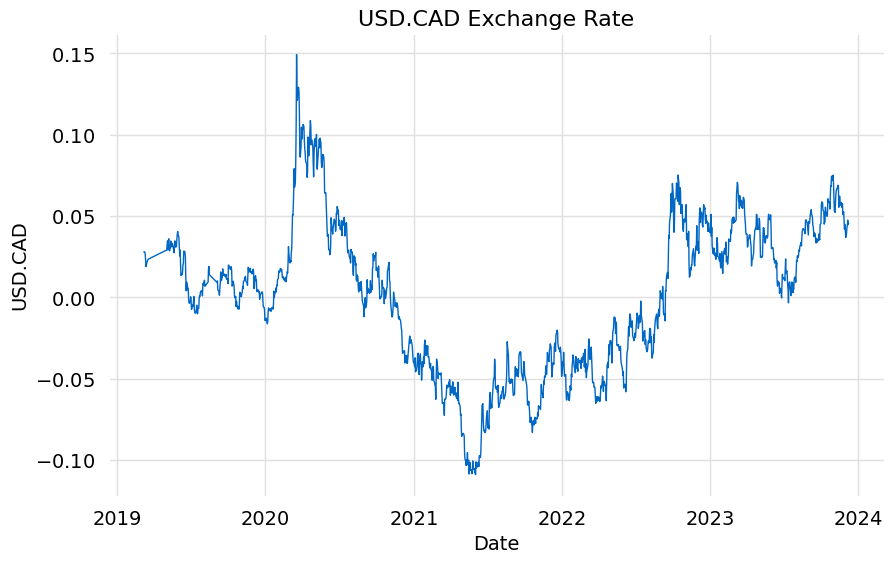

In [74]:
title = 'USD.CAD Exchange Rate'
xt = exch - exch_mean
curve(xt, date, title=title, xlabel="Date", ylabel="USD.CAD", labels=['USD.CAD', 'Mean'], lw=1)

In [75]:
result, result_model = ou.compute_mean_half_life_estimate(xt)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     5.072
Date:                Mon, 11 Dec 2023   Prob (F-statistic):             0.0245
Time:                        21:06:59   Log-Likelihood:                 5383.3
No. Observations:                1414   AIC:                        -1.076e+04
Df Residuals:                    1412   BIC:                        -1.075e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.258e-05      0.000     -0.088      0.930      -0.000       0.000
x1            -0.0069      0.003     -2.252      0.024      -0.013      -0.001
==============================================================================
Omnibus:                      147.091   Durbin-Watson:                   1.993
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              913.142
Skew:                          -0.246   Prob(JB):                    5.17e-199
Kurtosis:                       6.906   Cond. No.                         21.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [69]:
print(result_model.to_json(True))

{
   "est_model": "OLS",
   "const": {
      "est": -1.258405419962184e-05,
      "err": 0.00014302691659007262,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "9aff3bfb-8961-4325-8a15-027bfcc35ff2",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -0.00693961186813459,
         "err": 0.0030813265315984216,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "9aff3bfb-8961-4325-8a15-027bfcc35ff2",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.0035793399056737174,
   "param_transforms": [
      {
         "param": {
            "est": 99.88270147250576,
            "err": 44.34991811403532,
            "est_label": "$t_H$",
            "err_label": "$\\sigma_{t_H}$",
            "row": 0,
            "column": 0,
            "order": 1,
    

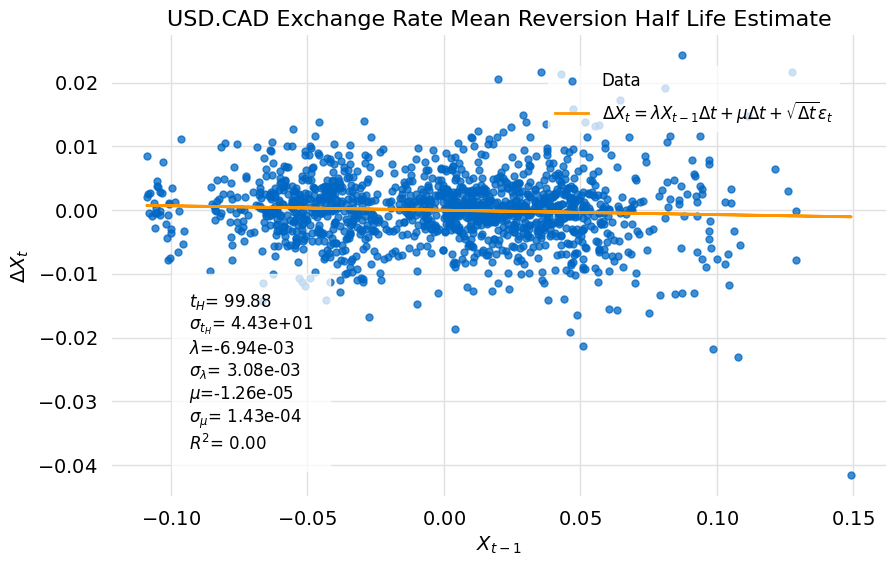

In [71]:
title = f"USD.CAD Exchange Rate Mean Reversion Half Life Estimate"
mean_reversion_halflife(xt, result_model, title=title)